In [1]:
md = loadmodel('./models/PIG_control_drag.mat');
md.inversion.iscontrol = 0;

In [2]:
md.initialization.vx = md.results.StressbalanceSolution.Vx;
md.initialization.vy = md.results.StressbalanceSolution.Vy;
md.initialization.vel = md.results.StressbalanceSolution.Vel;

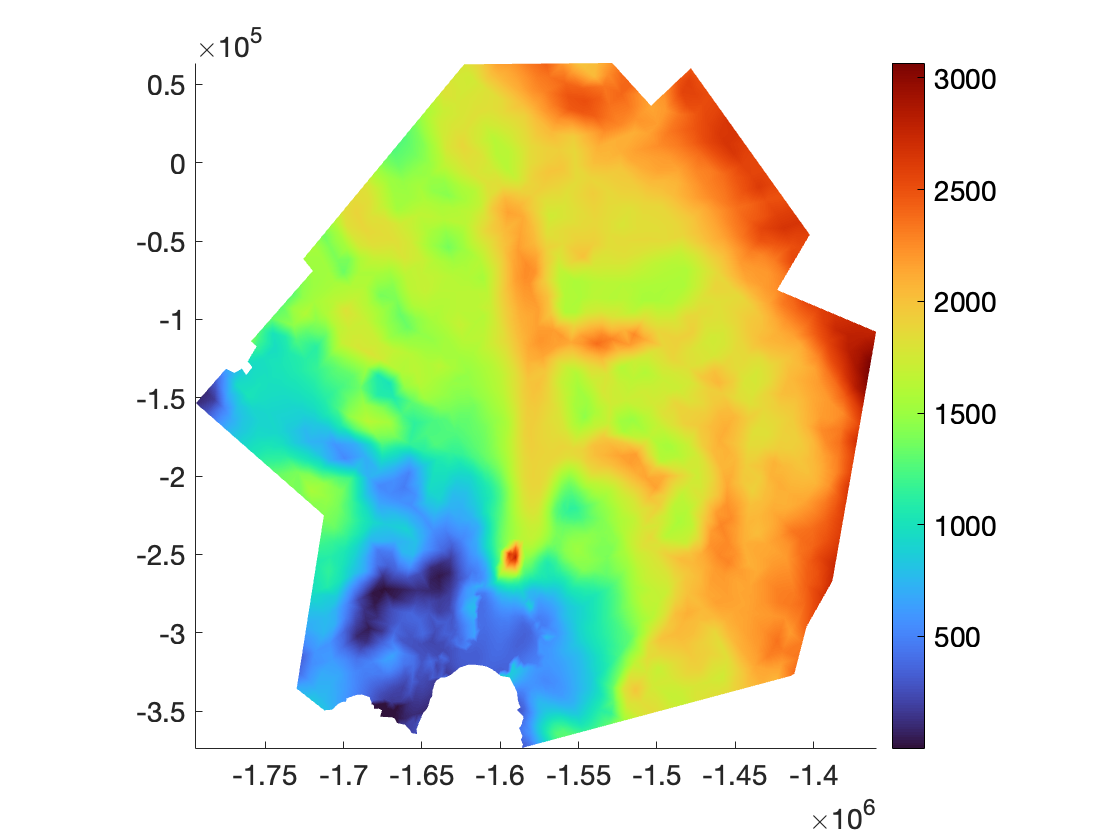

In [3]:
plotmodel(md, 'data', md.geometry.thickness)

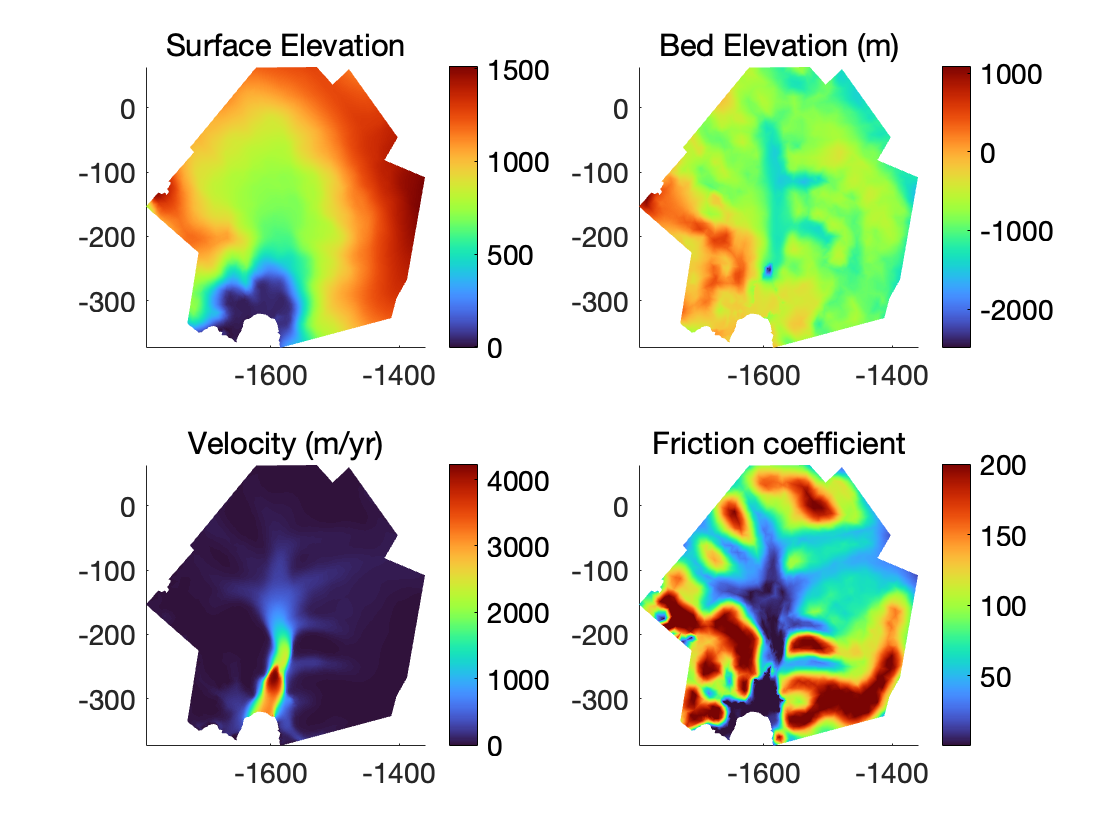

In [4]:
plotmodel(md,'data',md.geometry.surface,'title','Surface Elevation',...
'data',md.geometry.base,'title','Bed Elevation (m)',...
'data',md.initialization.vel,'title','Velocity (m/yr)',...
'data',md.friction.coefficient,'title','Friction coefficient',...
'unit#all','km')

In [10]:
md.basalforcings.groundedice_melting_rate=zeros(md.mesh.numberofvertices,1);
md.basalforcings.floatingice_melting_rate=zeros(md.mesh.numberofvertices,1);
md.basalforcings.geothermalflux=0.04*ones(md.mesh.numberofvertices,1);

md.hydrology = hydrologyshakti();
md.hydrology.englacial_input = 0.0*ones(md.mesh.numberofvertices,1);
md.hydrology.moulin_input = 0.0*ones(md.mesh.numberofvertices,1);
md.hydrology.head = 1.0*md.materials.rho_ice/md.materials.rho_freshwater*md.geometry.thickness + md.geometry.base;
md.hydrology.gap_height = 0.001*ones(md.mesh.numberofelements,1);
md.hydrology.bump_spacing = 0.1*ones(md.mesh.numberofelements,1);
md.hydrology.bump_height = 0.0*ones(md.mesh.numberofelements,1);
md.hydrology.reynolds= 1000*ones(md.mesh.numberofelements,1);

md.hydrology.spchead = NaN(md.mesh.numberofvertices,1);
pos=find(md.geometry.thickness<=10);
md.hydrology.spchead(pos)=0;
pos=find(md.mask.ice_levelset<0 & md.mask.ocean_levelset<0);
md.hydrology.spchead(pos)=0;
md.hydrology.neumannflux=zeros(md.mesh.numberofelements,1);

md.transient=deactivateall(md.transient);
% md.transient.isstressbalance=1;
md.transient.isstressbalance = 0;
md.transient.ishydrology=1;

Neff = md.materials.rho_ice*md.constants.g*md.geometry.thickness-md.materials.rho_water*md.constants.g*(md.hydrology.head - md.geometry.base); %Initial effective pressure
md.friction.effective_pressure=Neff;
md.friction.coupling = 4;

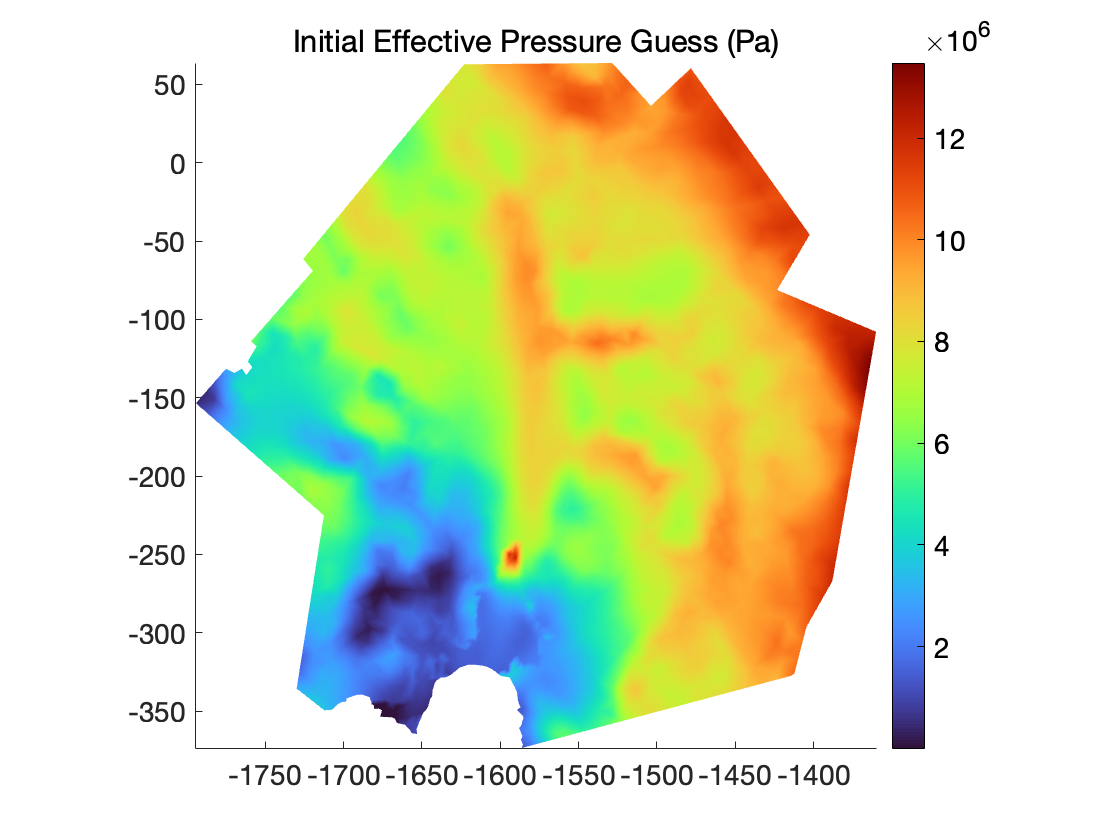

In [6]:
plotmodel(md,'data',md.friction.effective_pressure,'unit','km','title','Initial Effective Pressure Guess (Pa)')

In [11]:
md.cluster=generic('name', oshostname, 'np', 10);

md.timestepping.time_step = 1 * 3600 / md.constants.yts;
md.timestepping.final_time = 1 / 365; 
md.settings.output_frequency = 24;

% Run!
md.verbose.solution = 1; % Set to 1 to keep track of time step progress, 0 to turn off
md=solve(md,'Transient');

checking model consistency
marshalling file PIG.bin
launching solution sequence

Ice-sheet and Sea-level System Model (ISSM) version  4.24
(website: http://issm.jpl.nasa.gov forum: https://issm.ess.uci.edu/forum/)

call computational core:
iteration 1/24  time [yr]: 0.00 (time step: 0.00)
   computing effective pressure
solver residue too high!: norm(KU-F)/norm(F)=6.22139e+12 > 1e-06 (md.settings.solver_residue_threshold)
solver residue too high!: norm(KU-F)/norm(F)=1.14128e+12 > 1e-06 (md.settings.solver_residue_threshold)

[0] ??? Error using ==> ./modules/Solverx/Solverx.cpp:32
[0] Solverx error message: Recovery solver failed...


[1] ??? Error using ==> ./modules/Solverx/Solverx.cpp:32
[1] Solverx error message: Recovery solver failed...


[2] ??? Error using ==> ./modules/Solverx/Solverx.cpp:32
[2] Solverx error message: Recovery solver failed...


[3] ??? Error using ==> ./modules/Solverx/Solverx.cpp:32
[3] Solverx error message: Recovery solver failed...


[4] ??? Error using =

   Binary file PIG.outbin not found!                      
                                                            
   This typically happens when the run crashed.             
   Please check for error messages above or in the outlog   


In [8]:
plotmodel(md,'data',md.results.TransientSolution(end).EffectivePressure, 'caxis', [0 1e5])

Unrecognized field name "TransientSolution".